# Mercado inmobiliario de Melbourne — wrangling y preprocesamiento para ML

Este notebook explora, limpia y enriquece datos del mercado inmobiliario de Melbourne, y luego prepara una versión del dataset apta para modelos de Machine Learning. El recorrido se organiza en dos partes sobre la misma fuente de datos cruda:

- **Track A — Wrangling + Enriquecimiento (AirBnB).** Exploración con SQL sobre SQLite, selección de variables, análisis de nulos, eliminación de outliers por percentiles y enriquecimiento con datos agregados de AirBnB por código postal.
- **Track B — Preprocesamiento ML sobre Melbourne crudo.** Codificación OneHot, imputación iterativa con KNN (con y sin escalado) y reducción de dimensionalidad con PCA.

Las dos pipelines no se encadenan: Track B vuelve a partir del dataset crudo porque OHE, imputación y PCA requieren el conjunto completo de atributos, mientras que Track A produce un subconjunto reducido y enriquecido.


## Configuración e imports


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sqlalchemy import text

from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.decomposition import PCA

from src.io import load_melbourne, load_airbnb, save_processed
from src.db import get_engine, load_dataframes_to_db

sns.set_context('talk')


## Track A — Wrangling + Enriquecimiento (AirBnB)

En este track partimos de los datos crudos de Melbourne, sumamos un dataset de AirBnB (`cleansed_listings_dec18`) para enriquecer con información de mercado de alquileres, exploramos vía SQL y luego limpiamos en pandas hasta dejar un dataset listo para análisis.


### Carga de datos


In [3]:
melb_df = load_melbourne()
melb_df.head(3)


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0


In [4]:
interesting_cols = [
    'description', 'neighborhood_overview',
    'street', 'neighborhood', 'city', 'suburb', 'state', 'zipcode',
    'price', 'weekly_price', 'monthly_price',
    'latitude', 'longitude',
]
airbnb_df = load_airbnb(columns=interesting_cols)
airbnb_df.head(13)


,description,neighborhood_overview,street,neighborhood,city,suburb,state,zipcode,latitude,longitude,price,weekly_price,monthly_price
0,"House: Clean, New, Modern, Quite, Safe. 10Km f...",Very safe! Family oriented. Older age group.,"Bulleen, VIC, Australia",Balwyn North,Manningham,Bulleen,VIC,3105,-37.772684,145.092133,60,NaN,NaN
1,A large air conditioned room with queen spring...,This hip area is a crossroads between two grea...,"Brunswick East, VIC, Australia",Brunswick,Moreland,Brunswick East,VIC,3057,-37.766505,144.980736,35,200.0,803.0
2,RIGHT IN THE HEART OF ST KILDA! It doesn't get...,A stay at our apartment means you can enjoy so...,"St Kilda, VIC, Australia",St Kilda,Port Phillip,St Kilda,VIC,3182,-37.859755,144.977369,159,1253.0,4452.0
3,"Comfortable, relaxed house, a home away from ...","This is a great neighbourhood – it is quiet, y...","Thornbury, VIC, Australia",Thornbury,Darebin,Thornbury,VIC,3071,-37.758971,144.989228,50,250.0,920.0
4,We offer comfortable accommodation in Inner Me...,NaN,"St Kilda East, VIC, Australia",St Kilda East,Port Phillip,St Kilda East,VIC,3183,-37.864530,144.992238,69,400.0,1900.0
5,Please note: No booking will be accepted with ...,Our street is quiet & secluded but within walk...,"Berwick, VIC, Australia",NaN,Casey,Berwick,VIC,3806,-38.057254,145.339356,98,540.0,NaN
6,Easy to travel from and to the Airport; quiet ...,"The neighbours are quiet and friendly, please...","Reservoir, VIC, Australia",NaN,Darebin,Reservoir,VIC,3073,-37.697294,145.000816,50,335.0,1400.0
7,Comfortable and spacious room in an apartment ...,MCG (15min walk) Rod Laver Arena Fitzroy Garde...,"East Melbourne, VIC, Australia",NaN,Melbourne,East Melbourne,VIC,3002,-37.810267,144.985920,100,NaN,NaN
8,Study the exquisite detail of the antique Java...,Oakleigh is one of the most convenient and div...,"Oakleigh East, VIC, Australia",NaN,Monash,Oakleigh East,VIC,3166,-37.899601,145.114475,98,535.0,NaN
9,Light filled private room with Queen bed taste...,NaN,"Frankston, VIC, Australia",NaN,Frankston,Frankston,VIC,3199,-38.149320,145.141569,60,413.0,1540.0


### Validación y normalización de tipos

Antes de persistir en SQLite ajustamos los tipos que `to_sql` no infiere bien por sí solo: convertimos `Date` a datetime, forzamos `Postcode` a entero y normalizamos `zipcode` de AirBnB (que viene como texto y a veces con formato no canónico) a entero nullable.


In [5]:
print(melb_df.dtypes)

Suburb               str
Address              str
Rooms              int64
Type                 str
Price            float64
Method               str
SellerG              str
Date                 str
Distance         float64
Postcode         float64
Bedroom2         float64
Bathroom         float64
Car              float64
Landsize         float64
BuildingArea     float64
YearBuilt        float64
CouncilArea          str
Lattitude        float64
Longtitude       float64
Regionname           str
Propertycount    float64
dtype: object


In [6]:
melb_df['Date'] = pd.to_datetime(melb_df['Date'], errors='coerce')
melb_df['Postcode'] = melb_df['Postcode'].astype(int)
print(melb_df.dtypes)

Suburb                      str
Address                     str
Rooms                     int64
Type                        str
Price                   float64
Method                      str
SellerG                     str
Date             datetime64[us]
Distance                float64
Postcode                  int64
Bedroom2                float64
Bathroom                float64
Car                     float64
Landsize                float64
BuildingArea            float64
YearBuilt               float64
CouncilArea                 str
Lattitude               float64
Longtitude              float64
Regionname                  str
Propertycount           float64
dtype: object


In [7]:
print(airbnb_df.dtypes)

description                  str
neighborhood_overview        str
street                       str
neighborhood                 str
city                         str
suburb                       str
state                        str
zipcode                      str
latitude                 float64
longitude                float64
price                      int64
weekly_price             float64
monthly_price            float64
dtype: object


In [8]:
airbnb_df['zipcode'] = airbnb_df['zipcode'].astype(str).str.extract(r'(\d+)')
airbnb_df['zipcode'] = pd.to_numeric(airbnb_df['zipcode'], errors='coerce').astype('Int64')
airbnb_df.head(13)


,description,neighborhood_overview,street,neighborhood,city,suburb,state,zipcode,latitude,longitude,price,weekly_price,monthly_price
0,"House: Clean, New, Modern, Quite, Safe. 10Km f...",Very safe! Family oriented. Older age group.,"Bulleen, VIC, Australia",Balwyn North,Manningham,Bulleen,VIC,3105,-37.772684,145.092133,60,NaN,NaN
1,A large air conditioned room with queen spring...,This hip area is a crossroads between two grea...,"Brunswick East, VIC, Australia",Brunswick,Moreland,Brunswick East,VIC,3057,-37.766505,144.980736,35,200.0,803.0
2,RIGHT IN THE HEART OF ST KILDA! It doesn't get...,A stay at our apartment means you can enjoy so...,"St Kilda, VIC, Australia",St Kilda,Port Phillip,St Kilda,VIC,3182,-37.859755,144.977369,159,1253.0,4452.0
3,"Comfortable, relaxed house, a home away from ...","This is a great neighbourhood – it is quiet, y...","Thornbury, VIC, Australia",Thornbury,Darebin,Thornbury,VIC,3071,-37.758971,144.989228,50,250.0,920.0
4,We offer comfortable accommodation in Inner Me...,NaN,"St Kilda East, VIC, Australia",St Kilda East,Port Phillip,St Kilda East,VIC,3183,-37.864530,144.992238,69,400.0,1900.0
5,Please note: No booking will be accepted with ...,Our street is quiet & secluded but within walk...,"Berwick, VIC, Australia",NaN,Casey,Berwick,VIC,3806,-38.057254,145.339356,98,540.0,NaN
6,Easy to travel from and to the Airport; quiet ...,"The neighbours are quiet and friendly, please...","Reservoir, VIC, Australia",NaN,Darebin,Reservoir,VIC,3073,-37.697294,145.000816,50,335.0,1400.0
7,Comfortable and spacious room in an apartment ...,MCG (15min walk) Rod Laver Arena Fitzroy Garde...,"East Melbourne, VIC, Australia",NaN,Melbourne,East Melbourne,VIC,3002,-37.810267,144.985920,100,NaN,NaN
8,Study the exquisite detail of the antique Java...,Oakleigh is one of the most convenient and div...,"Oakleigh East, VIC, Australia",NaN,Monash,Oakleigh East,VIC,3166,-37.899601,145.114475,98,535.0,NaN
9,Light filled private room with Queen bed taste...,NaN,"Frankston, VIC, Australia",NaN,Frankston,Frankston,VIC,3199,-38.149320,145.141569,60,413.0,1540.0


### Agregación de AirBnB por código postal

Antes de la exploración con SQL agregamos los datos de AirBnB por `zipcode` para que la consulta de unión Melbourne x AirBnB devuelva información de mercado y no listados individuales. Seleccionamos `price`, `weekly_price` y `monthly_price` y aplicamos múltiples estadísticas:

- **`airbnb_price_median`**: mediana, robusta a outliers.
- **`airbnb_price_mean`**, **`airbnb_weekly_price_mean`**, **`airbnb_monthly_price_mean`**: medias como referencia general.
- **`airbnb_price_min` / `airbnb_price_max`**: rango del mercado.
- **`airbnb_record_count`**: cantidad de registros disponibles por zipcode.

Justificamos el uso de la mediana en lugar de la media porque suele haber grandes extremos que distorsionan la media, especialmente en alquileres diarios donde hay propiedades de lujo o con servicios premium.

Para que la información agregada sea estadísticamente significativa filtramos los códigos postales con al menos 5 registros.


In [9]:
airbnb_agg = airbnb_df.groupby('zipcode', dropna=True).agg(
    airbnb_price_median=('price', 'median'),
    airbnb_price_mean=('price', 'mean'),
    airbnb_weekly_price_mean=('weekly_price', 'mean'),
    airbnb_monthly_price_mean=('monthly_price', 'mean'),
    airbnb_price_min=('price', 'min'),
    airbnb_price_max=('price', 'max'),
    airbnb_record_count=('price', 'count'),
).reset_index()

airbnb_agg_filtered = airbnb_agg[airbnb_agg['airbnb_record_count'] >= 5]
airbnb_agg_filtered.head()


,zipcode,airbnb_price_median,airbnb_price_mean,airbnb_weekly_price_mean,airbnb_monthly_price_mean,airbnb_price_min,airbnb_price_max,airbnb_record_count
3,3000,129.0,150.470012,918.738956,3407.204651,0,9000,3368
5,3002,130.0,200.979695,956.379310,3712.714286,19,1550,197
6,3003,120.0,130.205993,760.200000,2629.500000,19,550,267
7,3004,130.0,158.271978,1061.171429,3759.925926,12,1771,728
8,3006,150.0,188.851735,1239.827273,4358.556701,17,2998,1268


### Exploración con SQL

Persistimos las dos tablas (`melbourne` con los datos crudos y `airbnb` con los agregados por zipcode) en un SQLite local y respondemos algunas preguntas con SQL para tener una primera intuición del dataset.


In [10]:
load_dataframes_to_db(melb_df, airbnb_agg_filtered)
engine = get_engine()


**Cantidad de registros por ciudad** — agrupados por `CouncilArea` y ordenados de mayor a menor.


In [11]:
with engine.connect() as conn:
    result = conn.execute(text("""
        SELECT CouncilArea AS ciudad, COUNT(*) AS cantidad
        FROM melbourne
        GROUP BY ciudad
        ORDER BY cantidad DESC
    """)).fetchall()

for row in result:
    print(row)


(None, 1369)
('Moreland', 1163)
('Boroondara', 1160)
('Moonee Valley', 997)
('Darebin', 934)
('Glen Eira', 848)
('Stonnington', 719)
('Maribyrnong', 692)
('Yarra', 647)
('Port Phillip', 628)
('Banyule', 594)
('Bayside', 489)
('Melbourne', 470)
('Hobsons Bay', 434)
('Brimbank', 424)
('Monash', 333)
('Manningham', 311)
('Whitehorse', 304)
('Kingston', 207)
('Whittlesea', 167)
('Hume', 164)
('Wyndham', 86)
('Maroondah', 80)
('Knox', 80)
('Melton', 66)
('Frankston', 53)
('Greater Dandenong', 52)
('Casey', 38)
('Nillumbik', 36)
('Yarra Ranges', 18)
('Cardinia', 8)
('Macedon Ranges', 7)
('Unavailable', 1)
('Moorabool', 1)


**Top 10 barrios por cantidad de registros** — limitamos a 10 porque son demasiados.


In [12]:
with engine.connect() as conn:
    result = conn.execute(text("""
        SELECT Suburb AS barrio, CouncilArea AS ciudad, COUNT(*) AS cantidad
        FROM melbourne
        GROUP BY barrio, ciudad
        ORDER BY cantidad DESC
        LIMIT 10
    """)).fetchall()

for row in result:
    print(row)


('Reservoir', 'Darebin', 323)
('Richmond', 'Yarra', 251)
('Bentleigh East', 'Glen Eira', 234)
('Preston', 'Darebin', 228)
('Brunswick', 'Moreland', 208)
('Essendon', 'Moonee Valley', 208)
('Hawthorn', 'Boroondara', 186)
('Brighton', 'Bayside', 176)
('Coburg', 'Moreland', 176)
('Northcote', 'Darebin', 175)


**Propiedades con más de 2 habitaciones por ciudad**.


In [13]:
with engine.connect() as conn:
    result = conn.execute(text("""
        SELECT CouncilArea AS ciudad, COUNT(*) AS cantidad
        FROM melbourne
        WHERE Rooms > 2
        GROUP BY ciudad
        ORDER BY cantidad DESC
    """)).fetchall()

for row in result:
    print(row)


(None, 1201)
('Boroondara', 791)
('Moreland', 777)
('Moonee Valley', 713)
('Darebin', 592)
('Glen Eira', 531)
('Banyule', 441)
('Maribyrnong', 434)
('Brimbank', 376)
('Bayside', 360)
('Hobsons Bay', 330)
('Stonnington', 304)
('Manningham', 295)
('Monash', 280)
('Yarra', 264)
('Whitehorse', 240)
('Port Phillip', 220)
('Kingston', 169)
('Hume', 152)
('Whittlesea', 149)
('Melbourne', 145)
('Wyndham', 82)
('Knox', 75)
('Maroondah', 68)
('Melton', 64)
('Frankston', 49)
('Greater Dandenong', 45)
('Casey', 37)
('Nillumbik', 34)
('Yarra Ranges', 17)
('Macedon Ranges', 7)
('Cardinia', 7)
('Unavailable', 1)
('Moorabool', 1)


**Precio promedio por tipo y ciudad**.


In [14]:
with engine.connect() as conn:
    result = conn.execute(text("""
        SELECT Type, CouncilArea AS ciudad, AVG(Price) AS precio_promedio
        FROM melbourne
        GROUP BY Type, ciudad
        ORDER BY precio_promedio DESC
    """)).fetchall()

for row in result:
    print(row)


('h', 'Boroondara', 2098358.8624338624)
('h', 'Stonnington', 2009337.4823151126)
('h', 'Bayside', 1986762.6623794213)
('h', 'Port Phillip', 1776054.716981132)
('t', 'Bayside', 1465253.8461538462)
('h', 'Whitehorse', 1437365.238095238)
('h', 'Melbourne', 1405010.3896103897)
('h', 'Yarra', 1387058.4825870646)
('t', 'Stonnington', 1371860.0)
('h', 'Glen Eira', 1352435.0808510638)
('h', 'Unavailable', 1325000.0)
('h', 'Manningham', 1312930.888030888)
('h', 'Monash', 1289668.2730923695)
('t', 'Boroondara', 1275743.6170212766)
('t', 'Port Phillip', 1255000.0)
('h', None, 1211861.2859437752)
('h', 'Moonee Valley', 1146283.640113798)
('h', 'Hobsons Bay', 1123561.6666666667)
('h', 'Kingston', 1069312.731543624)
('t', None, 1063550.7246376812)
('h', 'Darebin', 1059167.2554426705)
('t', 'Yarra', 1041978.7234042553)
('h', 'Banyule', 1029602.3706896552)
('t', 'Glen Eira', 1005799.1071428572)
('t', 'Manningham', 947950.0)
('t', 'Melbourne', 946287.5)
('h', 'Maribyrnong', 938990.5349794239)
('t', 'Wh

**Top 5 barrios con propiedades más caras (promedio)**.


In [15]:
with engine.connect() as conn:
    result = conn.execute(text("""
        SELECT Suburb AS barrio, AVG(Price) AS precio_promedio
        FROM melbourne
        GROUP BY barrio
        ORDER BY precio_promedio DESC
        LIMIT 5
    """)).fetchall()

for row in result:
    print(row)


('Kooyong', 2185000.0)
('Canterbury', 2180240.7407407407)
('Middle Park', 2082529.4117647058)
('Albert Park', 1941355.072463768)
('Brighton', 1930158.0)


**Join Melbourne x AirBnB agregado por código postal** — emparejamos cada propiedad con los precios agregados de AirBnB del mismo zipcode. Limitamos a 10 porque el resultado es muy grande.


In [16]:
with engine.connect() as conn:
    result = conn.execute(text("""
        SELECT m.Suburb, m.Postcode, m.Price,
               a.airbnb_price_mean, a.airbnb_weekly_price_mean, a.airbnb_monthly_price_mean
        FROM melbourne m
        JOIN airbnb a ON m.Postcode = a.zipcode
        LIMIT 10
    """)).fetchall()

for row in result:
    print(row)


('Abbotsford', 3067, 1480000.0, 130.62403100775194, 605.1521739130435, 2187.032258064516)
('Abbotsford', 3067, 1035000.0, 130.62403100775194, 605.1521739130435, 2187.032258064516)
('Abbotsford', 3067, 1465000.0, 130.62403100775194, 605.1521739130435, 2187.032258064516)
('Abbotsford', 3067, 850000.0, 130.62403100775194, 605.1521739130435, 2187.032258064516)
('Abbotsford', 3067, 1600000.0, 130.62403100775194, 605.1521739130435, 2187.032258064516)
('Abbotsford', 3067, 941000.0, 130.62403100775194, 605.1521739130435, 2187.032258064516)
('Abbotsford', 3067, 1876000.0, 130.62403100775194, 605.1521739130435, 2187.032258064516)
('Abbotsford', 3067, 1636000.0, 130.62403100775194, 605.1521739130435, 2187.032258064516)
('Abbotsford', 3067, 300000.0, 130.62403100775194, 605.1521739130435, 2187.032258064516)
('Abbotsford', 3067, 1097000.0, 130.62403100775194, 605.1521739130435, 2187.032258064516)


### Selección de variables

Para abordar el problema de predicción del valor de la propiedad seleccionamos un subconjunto de columnas y dejamos fuera otras que aportarían información redundante o difícil de modelar directamente.

**Variables seleccionadas:**

- **Suburb**: aporta contexto geográfico, muy influyente en los precios.
- **Rooms**: cantidad de habitaciones, influye directamente en el valor.
- **Type**: tipo de propiedad (casa, departamento, townhouse).
- **Method**: forma de venta (auction, private, etc.) puede afectar el precio.
- **Distance**: cercanía al centro de Melbourne.
- **CouncilArea**: barrio o distrito, fuerte relación con el valor inmobiliario.
- **Landsize**: tamaño del terreno, correlaciona con el precio.
- **BuildingArea**: superficie construida.
- **YearBuilt**: antigüedad de la propiedad.
- **Bathroom**: cantidad de baños.
- **Car**: capacidad de estacionamiento.
- **Price**: variable objetivo.

**Variables no seleccionadas:**

- **SellerG**, **Address**, **Postcode**, **Regionname**: información redundante o difícil de modelar directamente.
- **Date**: aunque podría servir para análisis temporal, no es el foco actual.


### Análisis de valores faltantes

Calculamos qué porcentaje de filas tienen al menos un valor faltante para tener una idea de la magnitud del problema antes de cualquier limpieza.


In [17]:
missing_rows_percent = melb_df.isnull().any(axis=1).mean() * 100
print(f"El porcentaje de filas que tienen al menos un valor faltante es: {missing_rows_percent:.2f}%")


El porcentaje de filas que tienen al menos un valor faltante es: 81.78%


### Distribución de variables numéricas

Visualizamos la distribución de las variables numéricas que vamos a usar para el análisis y la modelización.


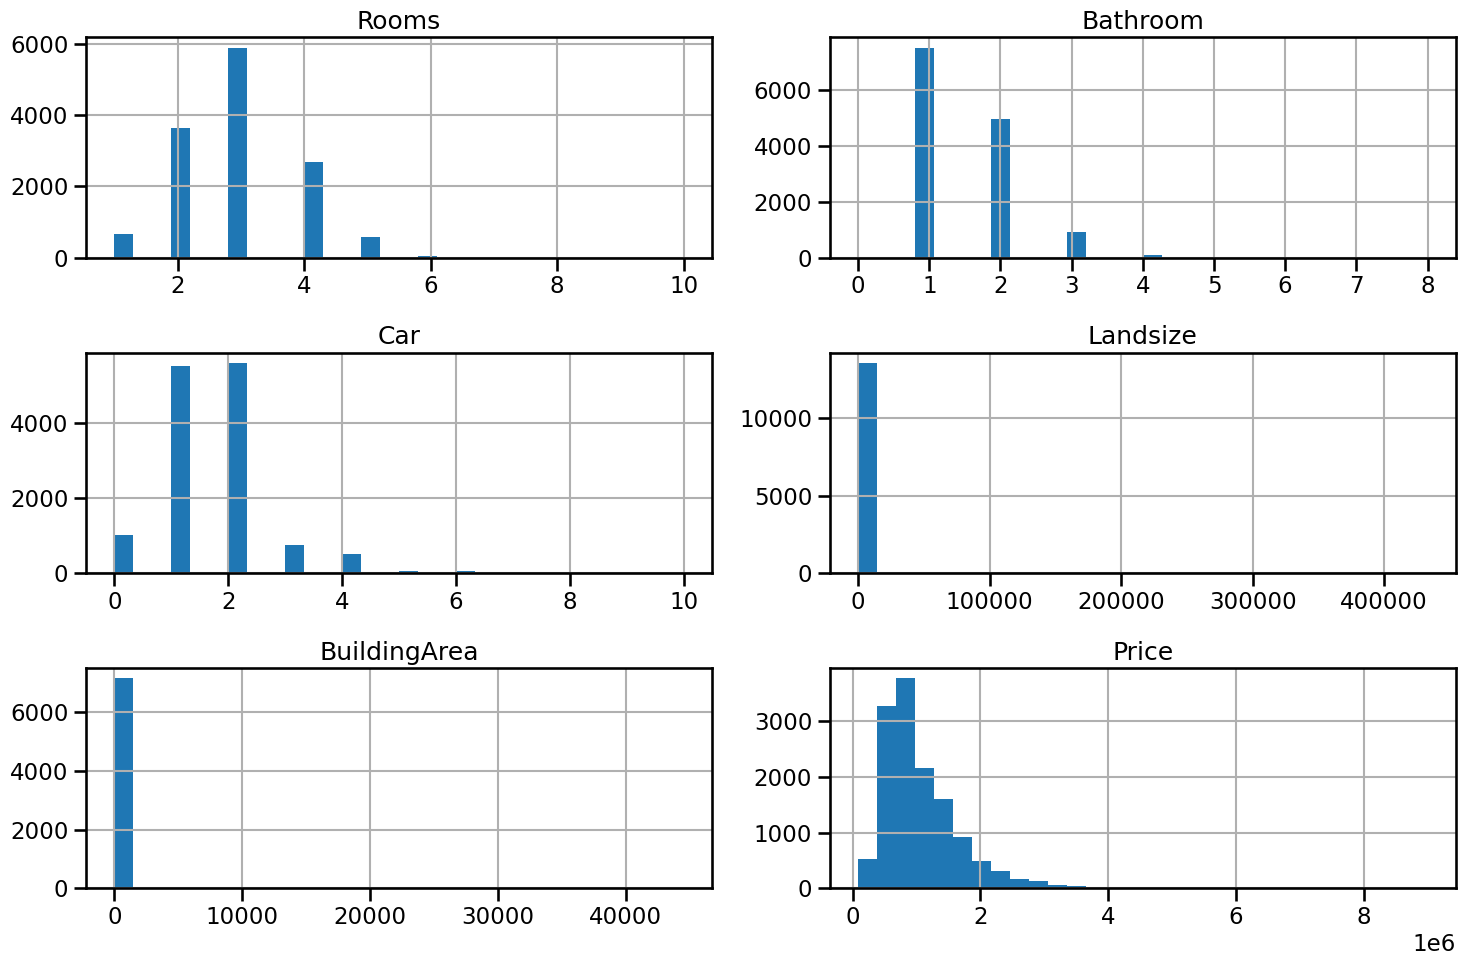

In [18]:
numeric_cols = ['Rooms', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'Price']
melb_df[numeric_cols].hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()


### Eliminación de valores extremos

Eliminamos outliers por recorte percentil. Probamos primero con el 1% en cada extremo y luego con el 5% para ver el efecto sobre la distribución de precios.


**Recorte 1% / 99%.**


In [19]:
lower = melb_df['Price'].quantile(0.01)
upper = melb_df['Price'].quantile(0.99)
melb_filt_df = melb_df[(melb_df['Price'] >= lower) & (melb_df['Price'] <= upper)]

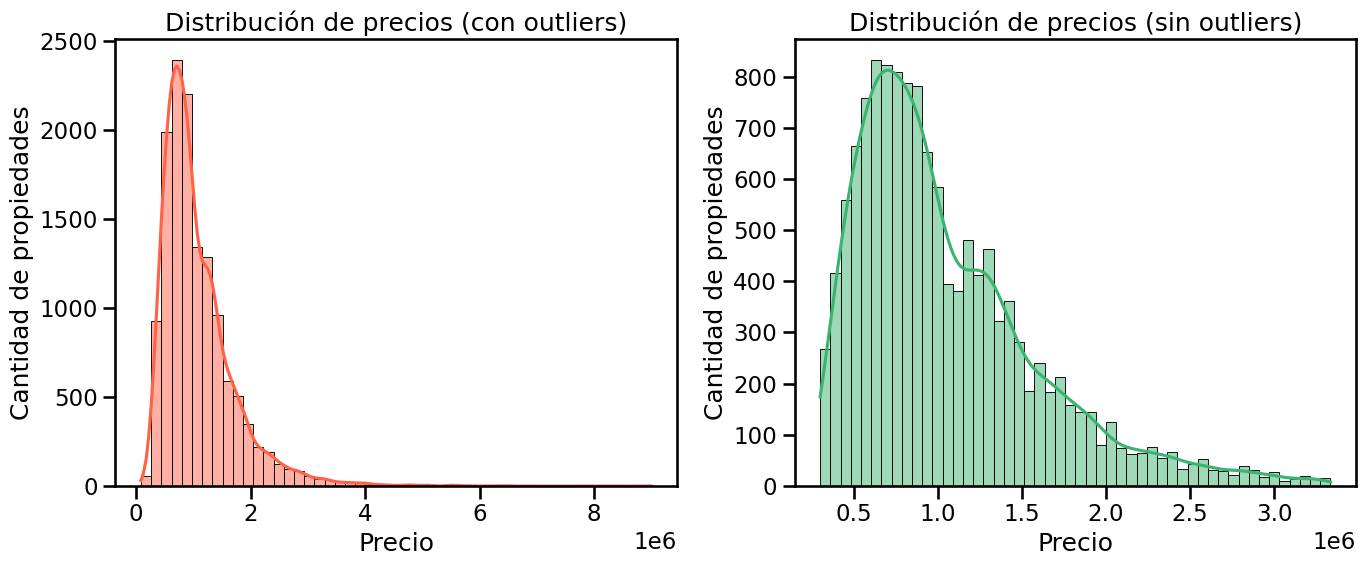

In [20]:
plt.figure(figsize=(14, 6))

# Original
plt.subplot(1, 2, 1)
sns.histplot(melb_df['Price'], bins=50, kde=True, color='tomato')
plt.title('Distribución de precios (con outliers)')
plt.xlabel('Precio')
plt.ylabel('Cantidad de propiedades')

# Sin outliers
plt.subplot(1, 2, 2)
sns.histplot(melb_filt_df['Price'], bins=50, kde=True, color='mediumseagreen')
plt.title('Distribución de precios (sin outliers)')
plt.xlabel('Precio')
plt.ylabel('Cantidad de propiedades')

plt.tight_layout()
plt.show()


**Recorte 5% / 95%** — probamos un recorte más agresivo.


In [21]:
lower = melb_df['Price'].quantile(0.05)
upper = melb_df['Price'].quantile(0.95)
melb_filt_df = melb_df[(melb_df['Price'] >= lower) & (melb_df['Price'] <= upper)]

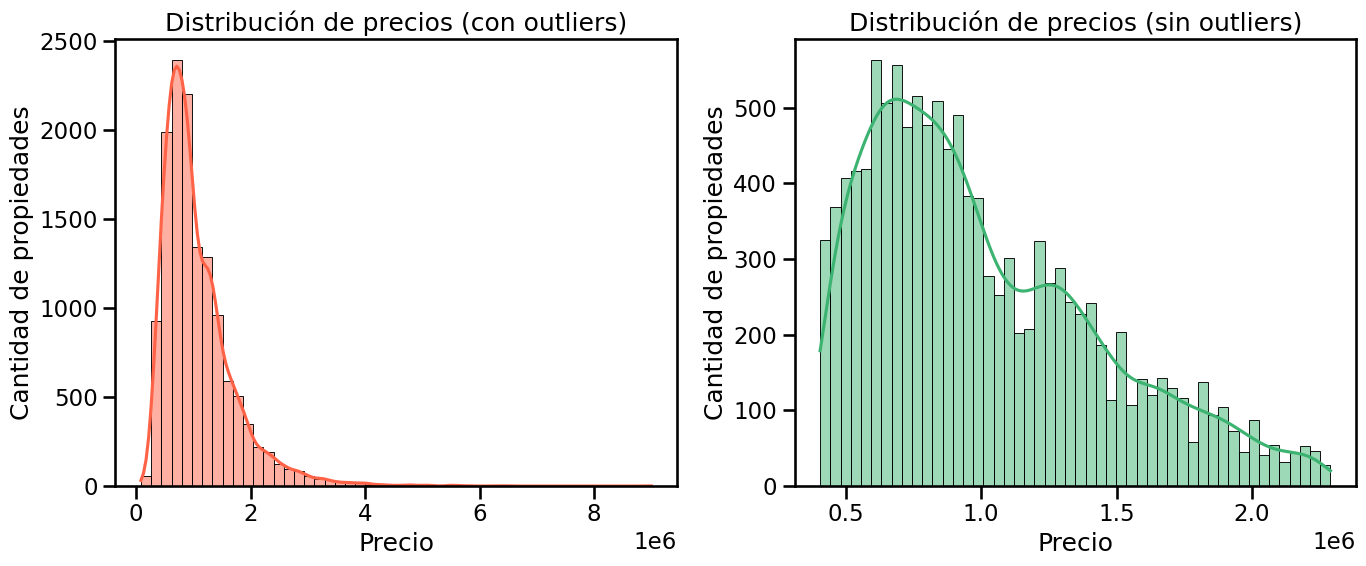

In [22]:
plt.figure(figsize=(14, 6))

# Original
plt.subplot(1, 2, 1)
sns.histplot(melb_df['Price'], bins=50, kde=True, color='tomato')
plt.title('Distribución de precios (con outliers)')
plt.xlabel('Precio')
plt.ylabel('Cantidad de propiedades')

# Sin outliers
plt.subplot(1, 2, 2)
sns.histplot(melb_filt_df['Price'], bins=50, kde=True, color='mediumseagreen')
plt.title('Distribución de precios (sin outliers)')
plt.xlabel('Precio')
plt.ylabel('Cantidad de propiedades')

plt.tight_layout()
plt.show()


### Merge con AirBnB y visualización por código postal

Unimos las propiedades con los precios agregados de AirBnB usando `Postcode` ↔ `zipcode` y graficamos el precio mediano de AirBnB por código postal sobre los zipcodes que pasaron el filtro de cantidad mínima de registros.


In [23]:
df_merged = melb_filt_df.merge(
    airbnb_agg_filtered,
    how='left',
    left_on='Postcode',
    right_on='zipcode',
)
df_merged.head(10)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Regionname,Propertycount,zipcode,airbnb_price_median,airbnb_price_mean,airbnb_weekly_price_mean,airbnb_monthly_price_mean,airbnb_price_min,airbnb_price_max,airbnb_record_count
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,2016-03-12,2.5,3067,...,Northern Metropolitan,4019.0,3067,100.0,130.624031,605.152174,2187.032258,28.0,900.0,258.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,2016-04-02,2.5,3067,...,Northern Metropolitan,4019.0,3067,100.0,130.624031,605.152174,2187.032258,28.0,900.0,258.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,2017-04-03,2.5,3067,...,Northern Metropolitan,4019.0,3067,100.0,130.624031,605.152174,2187.032258,28.0,900.0,258.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,2017-04-03,2.5,3067,...,Northern Metropolitan,4019.0,3067,100.0,130.624031,605.152174,2187.032258,28.0,900.0,258.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,2016-04-06,2.5,3067,...,Northern Metropolitan,4019.0,3067,100.0,130.624031,605.152174,2187.032258,28.0,900.0,258.0
5,Abbotsford,129 Charles St,2,h,941000.0,S,Jellis,2016-07-05,2.5,3067,...,Northern Metropolitan,4019.0,3067,100.0,130.624031,605.152174,2187.032258,28.0,900.0,258.0
6,Abbotsford,124 Yarra St,3,h,1876000.0,S,Nelson,2016-07-05,2.5,3067,...,Northern Metropolitan,4019.0,3067,100.0,130.624031,605.152174,2187.032258,28.0,900.0,258.0
7,Abbotsford,98 Charles St,2,h,1636000.0,S,Nelson,2016-08-10,2.5,3067,...,Northern Metropolitan,4019.0,3067,100.0,130.624031,605.152174,2187.032258,28.0,900.0,258.0
8,Abbotsford,10 Valiant St,2,h,1097000.0,S,Biggin,2016-08-10,2.5,3067,...,Northern Metropolitan,4019.0,3067,100.0,130.624031,605.152174,2187.032258,28.0,900.0,258.0
9,Abbotsford,411/8 Grosvenor St,2,u,700000.0,VB,Jellis,2016-12-11,2.5,3067,...,Northern Metropolitan,4019.0,3067,100.0,130.624031,605.152174,2187.032258,28.0,900.0,258.0


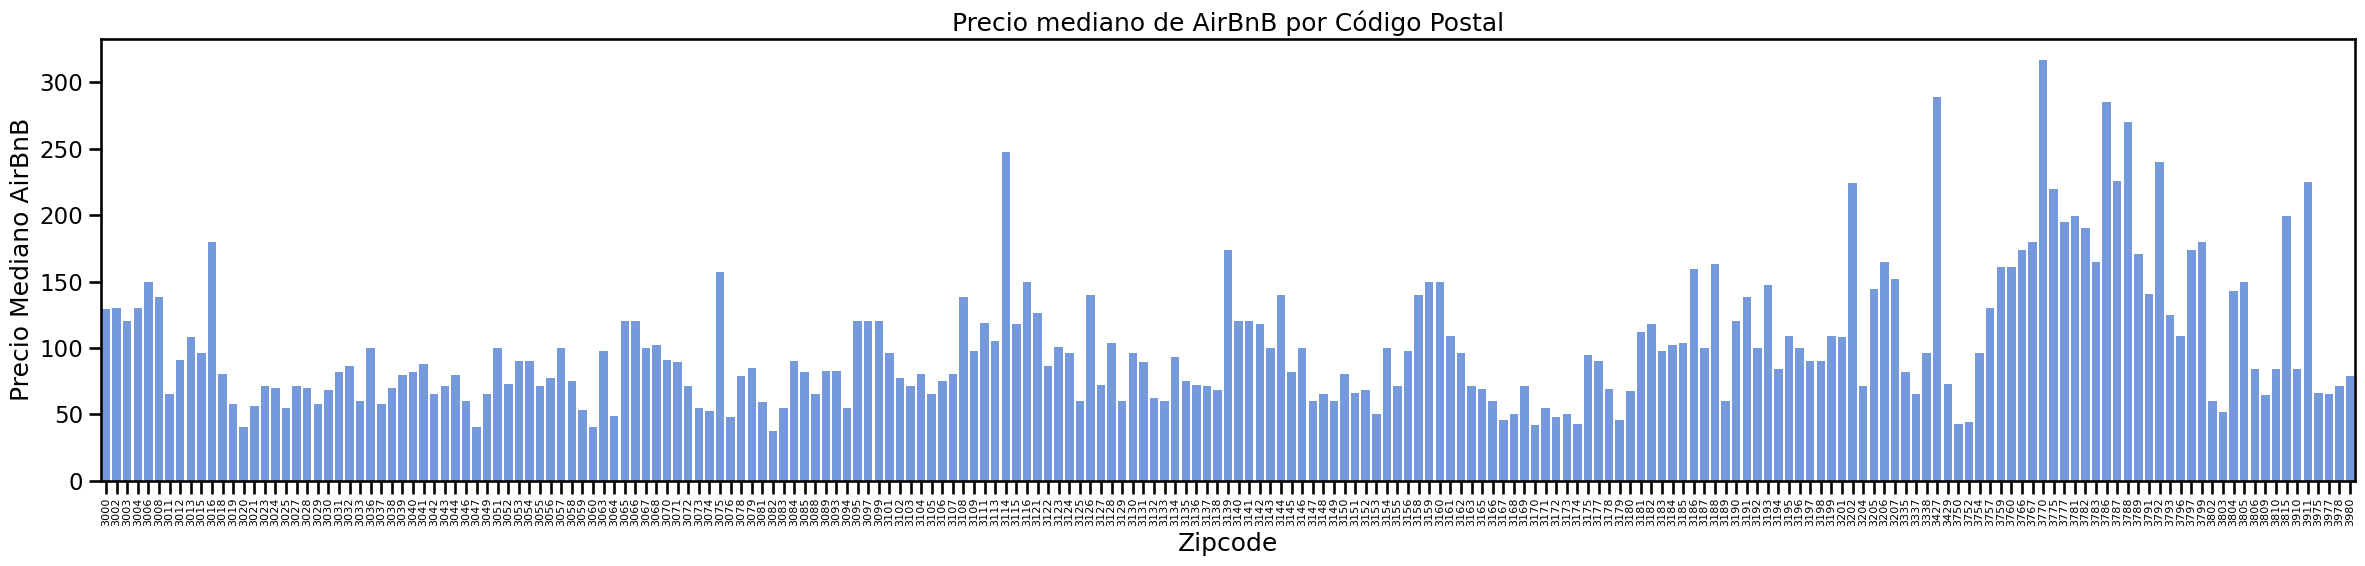

In [24]:
plt.figure(figsize=(24, 6))
sns.barplot(data=airbnb_agg_filtered, x='zipcode', y='airbnb_price_median', color='cornflowerblue')
plt.xticks(rotation=90)
plt.title('Precio mediano de AirBnB por Código Postal')
plt.xlabel('Zipcode')
plt.ylabel('Precio Mediano AirBnB')
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()


### Otras dimensiones que podrían enriquecer el dataset

Más allá del zipcode, hay otras claves de unión que podrían aportar señal — algunas las tenemos a mano y otras requerirían fuentes externas o anotación experta:

- **Suburb / CouncilArea**: permitiría unir a un nivel más fino que el zipcode, pero requiere alinear nomenclaturas entre datasets (con ayuda de anotadores expertos).
- **Coordenadas geoespaciales (latitude / longitude)**: con ellas podríamos calcular las *n* ubicaciones más cercanas y construir features de cercanía a puntos de interés.

Creemos que la cercanía espacial es un factor clave en el valor inmobiliario, y muchas veces barrios limítrofes pueden tener diferencias importantes de precios — un feature de vecindad espacial debería capturar mejor esos efectos que un agregado puro por zipcode.

Variables que **no** están en los datos y serían valiosas para predecir mejor el precio: indicadores de seguridad del barrio, calidad del transporte público, distancia a amenidades (escuelas, hospitales, parques) y nivel socioeconómico de la zona.


### Persistencia del dataset enriquecido

Cerramos Track A guardando el dataset combinado en `data/processed/melb_clean.csv`.


In [25]:
df_final = df_merged.copy()
out_path = save_processed(df_final, 'melb_clean.csv')
print(f'Track A escrito en: {out_path}')


Track A escrito en: /Users/nicochade/Documents/projects/portfolio/real-estate-wrangling-ml-project/data/processed/melb_clean.csv


## Track B — Preprocesamiento ML sobre Melbourne crudo

El preprocesamiento para Machine Learning (OneHotEncoding, imputación iterativa con KNN, PCA) requiere los 21 atributos originales del dataset Melbourne. La salida de Track A es un subconjunto reducido y enriquecido con AirBnB, así que en este track recargamos los datos crudos para tener todas las columnas disponibles.


In [26]:
melb_df = load_melbourne()
melb_df.head(3)


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0


### Codificación OneHot de variables categóricas

Excluimos `BuildingArea` y `YearBuilt` (las reincorporaremos después para imputarlas), separamos numéricas y categóricas, reducimos las categorías a las 10 más frecuentes (con un cubo "Other" para el resto) y aplicamos `OneHotEncoder`. El resultado lo concatenamos con las variables numéricas en una matriz de numpy y luego en un DataFrame.


In [27]:
melb_df_reduced = melb_df.drop(columns=['BuildingArea', 'YearBuilt'])


In [28]:
num_cols = melb_df_reduced.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = melb_df_reduced.select_dtypes(include=['object', 'category', 'str']).columns.tolist()

In [29]:
categories_list = []
for col in cat_cols:
    top_10 = melb_df_reduced[col].value_counts().nlargest(10).index.tolist()
    melb_df_reduced[col] = melb_df_reduced[col].apply(lambda x: x if x in top_10 else 'Other')
    categories_list.append(top_10 + ['Other'])


In [30]:
encoder = OneHotEncoder(categories=categories_list, sparse_output=False, handle_unknown='ignore')
cat_encoded = encoder.fit_transform(melb_df_reduced[cat_cols])

array_encoded = np.hstack([melb_df_reduced[num_cols].values, cat_encoded])


In [31]:
encoded_cat_names = encoder.get_feature_names_out(cat_cols)
columns_encoded = num_cols + encoded_cat_names.tolist()

df_encoded = pd.DataFrame(array_encoded, columns=columns_encoded)
print(df_encoded.shape)
df_encoded.head(10)


(13580, 85)


,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,Lattitude,Longtitude,...,CouncilArea_Other,Regionname_Southern Metropolitan,Regionname_Northern Metropolitan,Regionname_Western Metropolitan,Regionname_Eastern Metropolitan,Regionname_South-Eastern Metropolitan,Regionname_Eastern Victoria,Regionname_Northern Victoria,Regionname_Western Victoria,Regionname_Other
0,2.0,1480000.0,2.5,3067.0,2.0,1.0,1.0,202.0,-37.7996,144.9984,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,1035000.0,2.5,3067.0,2.0,1.0,0.0,156.0,-37.8079,144.9934,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,1465000.0,2.5,3067.0,3.0,2.0,0.0,134.0,-37.8093,144.9944,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3.0,850000.0,2.5,3067.0,3.0,2.0,1.0,94.0,-37.7969,144.9969,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4.0,1600000.0,2.5,3067.0,3.0,1.0,2.0,120.0,-37.8072,144.9941,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,2.0,941000.0,2.5,3067.0,2.0,1.0,0.0,181.0,-37.8041,144.9953,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,3.0,1876000.0,2.5,3067.0,4.0,2.0,0.0,245.0,-37.8024,144.9993,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,2.0,1636000.0,2.5,3067.0,2.0,1.0,2.0,256.0,-37.8060,144.9954,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,1.0,300000.0,2.5,3067.0,1.0,1.0,1.0,0.0,-37.8008,144.9973,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,2.0,1097000.0,2.5,3067.0,3.0,1.0,2.0,220.0,-37.8010,144.9989,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Imputación con KNN

Volvemos a sumar las columnas `BuildingArea` y `YearBuilt` (con sus NaN originales) sobre la matriz codificada y usamos `IterativeImputer` con `KNeighborsRegressor` para imputar valores faltantes. Comparamos la imputación sin escalado previo con la imputación sobre datos escalados con `MinMaxScaler` (revirtiendo el escalado al final).


In [32]:
df_encoded[['BuildingArea', 'YearBuilt']] = melb_df[['BuildingArea', 'YearBuilt']]


**Imputación sin escalado.**


In [33]:
numeric_data = df_encoded.select_dtypes(include='number')

imputer_no_scaling = IterativeImputer(estimator=KNeighborsRegressor(), random_state=10)
imputed_no_scaling = imputer_no_scaling.fit_transform(numeric_data)

imputed_df_no_scaling = pd.DataFrame(
    imputed_no_scaling, columns=numeric_data.columns, index=melb_df.index,
)


**Imputación con escalado previo (MinMaxScaler).**


In [34]:
minmax_scaler = MinMaxScaler()
scaled_data = minmax_scaler.fit_transform(numeric_data)

imputer_scaling = IterativeImputer(estimator=KNeighborsRegressor(), random_state=10)
imputed_scaled = imputer_scaling.fit_transform(scaled_data)

imputed_with_scaling = minmax_scaler.inverse_transform(imputed_scaled)

imputed_df_scaling = pd.DataFrame(
    imputed_with_scaling, columns=numeric_data.columns, index=melb_df.index,
)


**Distribuciones antes / después de imputar (sin escalar y con escalado).**


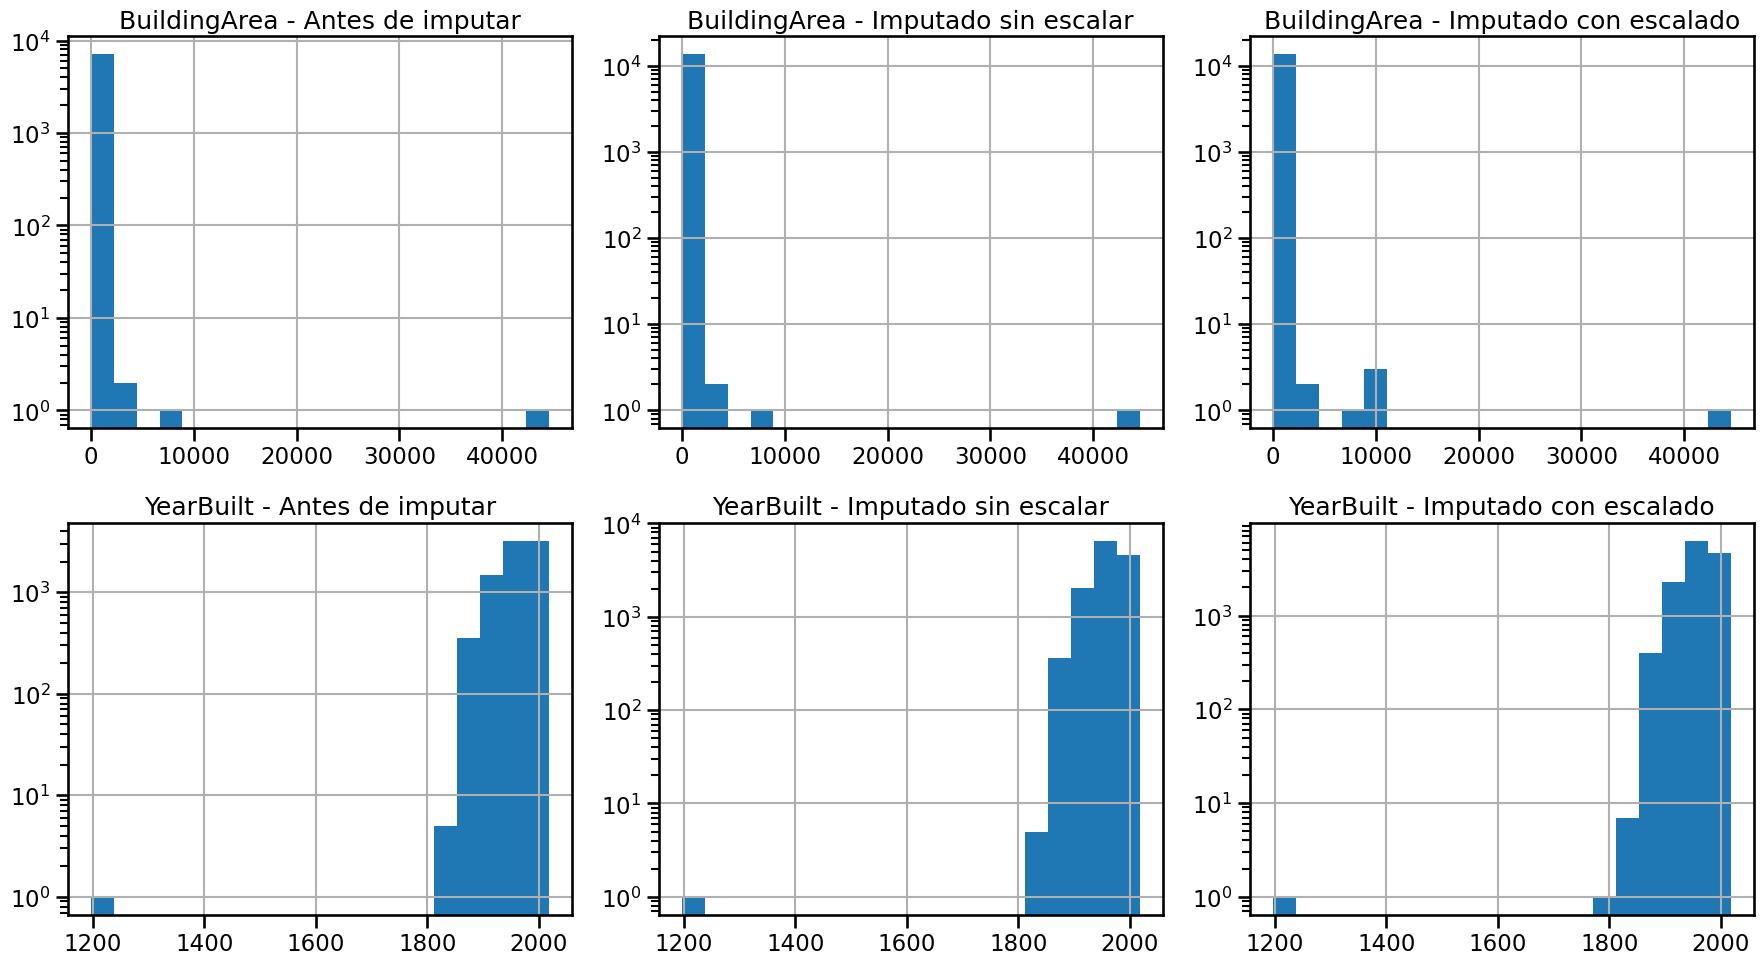

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Antes de la imputación
melb_df['BuildingArea'].hist(ax=axes[0, 0], bins=20, log=True)
axes[0, 0].set_title('BuildingArea - Antes de imputar')

melb_df['YearBuilt'].hist(ax=axes[1, 0], bins=20, log=True)
axes[1, 0].set_title('YearBuilt - Antes de imputar')

# 2. Imputado sin escalar
imputed_df_no_scaling['BuildingArea'].hist(ax=axes[0, 1], bins=20, log=True)
axes[0, 1].set_title('BuildingArea - Imputado sin escalar')

imputed_df_no_scaling['YearBuilt'].hist(ax=axes[1, 1], bins=20, log=True)
axes[1, 1].set_title('YearBuilt - Imputado sin escalar')

# 3. Imputado con escalado
imputed_df_scaling['BuildingArea'].hist(ax=axes[0, 2], bins=20, log=True)
axes[0, 2].set_title('BuildingArea - Imputado con escalado')

imputed_df_scaling['YearBuilt'].hist(ax=axes[1, 2], bins=20, log=True)
axes[1, 2].set_title('YearBuilt - Imputado con escalado')

plt.tight_layout()
plt.show()


**Conclusión sobre la imputación.** Antes de imputar, los histogramas tienen "huecos" (NaNs), o colas muy raras si hay pocos datos no nulos, lo que obliga a rellenar esos huecos. Si imputamos sin estandarizar, las predicciones se ven afectadas porque KNN se basa en distancias entre puntos: variables con escalas más grandes dominan el cálculo y sesgan el resultado. Con escalado previo, todas las variables aportan en la misma medida y la imputación es más coherente.


### Reducción de dimensionalidad con PCA

PCA es una técnica sensible a la escala porque busca direcciones de máxima varianza, así que estandarizamos primero con `StandardScaler` (media 0, desviación estándar 1) para que las variables con rangos grandes no dominen las componentes principales. Aplicamos PCA con `n = min(20, X.shape[1])` componentes y agregamos las dos primeras al dataset.

In [36]:
numeric_data = imputed_df_scaling  # se podría usar imputed_df_no_scaling

standard_scaler = StandardScaler()
scaled_data = standard_scaler.fit_transform(numeric_data)

pd.DataFrame(scaled_data, columns=numeric_data.columns).head()


,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,Lattitude,Longtitude,...,Regionname_Northern Metropolitan,Regionname_Western Metropolitan,Regionname_Eastern Metropolitan,Regionname_South-Eastern Metropolitan,Regionname_Eastern Victoria,Regionname_Northern Victoria,Regionname_Western Victoria,Regionname_Other,BuildingArea,YearBuilt
0,-0.981463,0.632448,-1.301485,-0.422415,-0.947035,-0.772376,-0.633520,-0.089316,0.121160,0.030640,...,1.578291,-0.52657,-0.34854,-0.185129,-0.062595,-0.05503,-0.0486,0.0,-0.124810,-0.608524
1,-0.981463,-0.063640,-1.301485,-0.422415,-0.947035,-0.772376,-1.673558,-0.100843,0.016437,-0.017478,...,1.578291,-0.52657,-0.34854,-0.185129,-0.062595,-0.05503,-0.0486,0.0,-0.167051,-1.907777
2,0.064876,0.608984,-1.301485,-0.422415,0.088284,0.673367,-1.673558,-0.106356,-0.001227,-0.007855,...,1.578291,-0.52657,-0.34854,-0.185129,-0.062595,-0.05503,-0.0486,0.0,0.003354,-1.907777
3,0.064876,-0.353025,-1.301485,-0.422415,0.088284,0.673367,-0.633520,-0.116380,0.155226,0.016204,...,1.578291,-0.52657,-0.34854,-0.185129,-0.062595,-0.05503,-0.0486,0.0,-0.072488,-0.439318
4,1.111216,0.820157,-1.301485,-0.422415,0.088284,-0.772376,0.406519,-0.109864,0.025269,-0.010742,...,1.578291,-0.52657,-0.34854,-0.185129,-0.062595,-0.05503,-0.0486,0.0,-0.015847,1.536756


In [37]:
n_components = min(20, scaled_data.shape[1])
pca = PCA(n_components=n_components)
pca_result = pca.fit_transform(scaled_data)

In [38]:
explained_variance = pca.explained_variance_ratio_
print(f"Varianza explicada por cada componente:\n{explained_variance}")
print(f"Varianza explicada acumulada: {explained_variance.cumsum()}")


Varianza explicada por cada componente:
[0.0569376  0.04895378 0.04052744 0.03486712 0.02639654 0.02407186
 0.02388372 0.02234119 0.02199251 0.02130727 0.02091944 0.01948169
 0.01865276 0.01779896 0.01697704 0.01676565 0.01524586 0.01442481
 0.01391527 0.01384198]
Varianza explicada acumulada: [0.0569376  0.10589138 0.14641882 0.18128594 0.20768248 0.23175434
 0.25563806 0.27797925 0.29997176 0.32127904 0.34219848 0.36168017
 0.38033293 0.39813188 0.41510893 0.43187458 0.44712044 0.46154525
 0.47546052 0.48930251]


Las primeras dos componentes principales resumen una parte importante de la varianza en solo dos dimensiones, lo que permite visualizar los datos reducidos y detectar patrones, clusters o tendencias.


In [39]:
pca_df = pd.DataFrame(
    pca_result[:, :2], columns=['pca1', 'pca2'], index=numeric_data.index,
)

df_with_pca = numeric_data.copy()
df_with_pca['pca1'] = pca_df['pca1']
df_with_pca['pca2'] = pca_df['pca2']


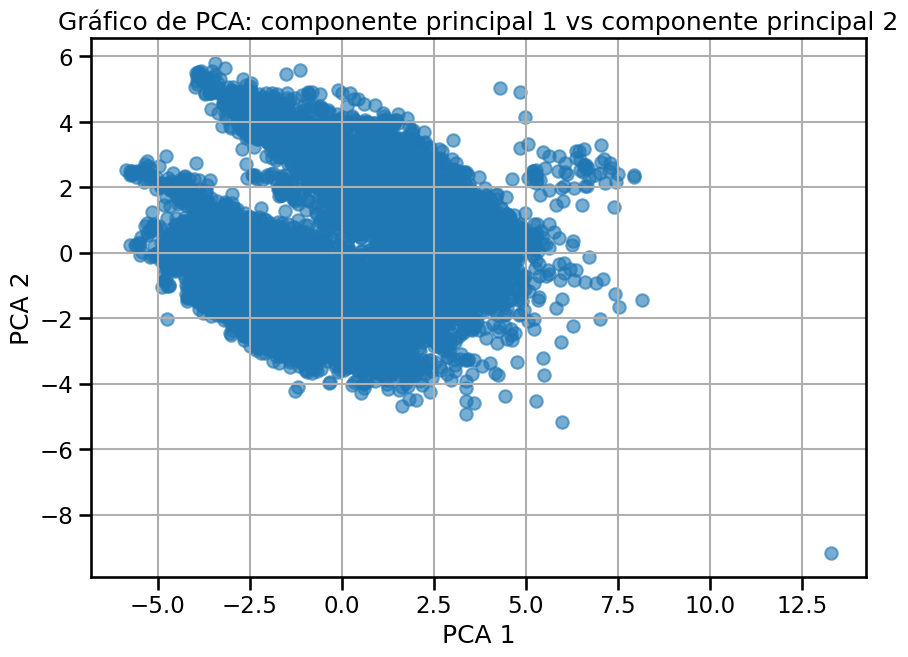

In [40]:
plt.figure(figsize=(10, 7))
plt.scatter(df_with_pca['pca1'], df_with_pca['pca2'], alpha=0.6)
plt.title('Gráfico de PCA: componente principal 1 vs componente principal 2')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.grid(True)
plt.show()


### Persistencia del dataset listo para ML

Guardamos el dataset procesado (variables imputadas + dos componentes principales de PCA) en `data/processed/melb_processed_with_pca.csv` para reutilizarlo en futuros análisis o como input de modelos.


In [41]:
processed_melb_df = df_with_pca.copy()
out_path = save_processed(processed_melb_df, 'melb_processed_with_pca.csv')
print(f'Track B escrito en: {out_path}')


Track B escrito en: /Users/nicochade/Documents/projects/portfolio/real-estate-wrangling-ml-project/data/processed/melb_processed_with_pca.csv


## Conclusiones y próximos pasos

**Sobre la selección de variables y los datos enriquecidos.** Para predecir el valor de una propiedad, el conjunto de variables seleccionadas captura las dimensiones principales (geografía, tamaño, tipología, estacionamiento, fecha de construcción). El enriquecimiento con datos agregados de AirBnB por código postal aporta una señal de mercado de alquileres que complementa el precio de venta. Usar la mediana en lugar de la media es clave para robustecer ese agregado frente a outliers.

**Sobre el preprocesamiento para ML.** El escalado previo a la imputación con KNN cambia cualitativamente el resultado: sin escalar, las variables con valores grandes dominan el cálculo de distancia y la imputación queda sesgada. Con escalado previo (y reversión posterior) la imputación es consistente con la distribución original. Lo mismo aplica a PCA: estandarizar antes de aplicarlo es necesario para evitar que las componentes principales reflejen escalas en lugar de varianza informativa.

**Análisis breve de PCA.** La varianza explicada por las primeras componentes muestra que una cantidad reducida de componentes captura una proporción significativa de la variabilidad: hay correlaciones entre las variables numéricas que permiten representar la información con menos dimensiones sin perder demasiada información. El gráfico PCA1 vs PCA2 muestra dispersión y agrupamientos que podrían corresponder a distintas tipologías o características de las propiedades — útil para futuros análisis exploratorios o modelado.

**Próximos pasos.** Incorporar features de cercanía espacial usando latitud/longitud, explorar fuentes externas para indicadores socioeconómicos y de transporte, y entrenar modelos de regresión sobre el dataset procesado para validar el aporte real de cada transformación al error de predicción.
